<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_3_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **2.4 ONLY PS and S**

### Library/Module Import

In [ ]:
%reset -f
import numpy as np
import pandas as pd
import time
import datetime
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler,random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import transformers
from transformers import BertForSequenceClassification, BertConfig,BertTokenizer,get_linear_schedule_with_warmup
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

### Preprocessing of dataset, *train_df*

In [ ]:
train_df = pd.read_pickle('.../PS_S_df_train_df.pkl')
train_df['Utterance'] = train_df['Utterance'].astype(str)

In [ ]:
possible_labels = train_df.Categories.unique()
print(f'\n {len(possible_labels)} Categories involved:')
print(possible_labels)


 10 Categories involved:
['SS3' 'SS2' 'SC2' 'SC1' 'SS1' 'SS6' 'SS5' 'SS8' 'SS4' 'SS7']


### BERT Tokenizer


In [ ]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

input_ids = []
attention_masks = []

for utterance in train_df["Utterance"]:
    encoded_dict = tokenizer.encode_plus(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        max_length=128,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt'     # Return pytorch tensors.
                   )

    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

labels = train_df.label.values
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

#### Train-validation split
80% of data is split into train and 20% to validation sets.

In [ ]:
dataset = TensorDataset(input_ids, attention_masks, labels)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

torch.manual_seed(42)

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print('{:>5,} training samples'.format(train_size))
print('{:>5,} validation samples'.format(val_size))

batch_size = 32


train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

validation_dataloader = DataLoader(
            val_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 10,
    output_attentions = False,
    output_hidden_states = False,
)

model = model.to(device)

optimizer = AdamW(model.parameters(),
                  lr = 2e-5,
                  eps = 1e-8
                )

2,915 training samples
  729 validation samples


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


### Fine tuning the model

In [ ]:
# Number of training epochs
epochs = 100

# Total number of training steps is [number of batches] x [number of epochs].
total_steps = len(train_dataloader) * epochs


scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0,
                                            num_training_steps = total_steps)


def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))


======== Epoch 1 / 100 ========
Training...
Model for epoch 1 saved in "/content/drive/MyDrive/AIED25/M2_BERT/PS_S_V2/PS_S_EPOCH/categories_BERT_epoch_1.model"

  Avg. training loss: 1.65
  Training epoch took: 0:01:01

Running Validation...

  Avg. validation loss: 1.38
  Avg. accuracy: 0.551
  Avg. recall: 0.551
  Avg. precision: 0.447
  Avg. F1: 0.491
  Validation took: 0:00:05

======== Epoch 2 / 100 ========
Training...
Model for epoch 2 saved in "/content/drive/MyDrive/AIED25/M2_BERT/PS_S_V2/PS_S_EPOCH/categories_BERT_epoch_2.model"

  Avg. training loss: 1.22
  Training epoch took: 0:01:01

Running Validation...

  Avg. validation loss: 1.27
  Avg. accuracy: 0.569
  Avg. recall: 0.568
  Avg. precision: 0.48
  Avg. F1: 0.508
  Validation took: 0:00:05

======== Epoch 3 / 100 ========
Training...
Model for epoch 3 saved in "/content/drive/MyDrive/AIED25/M2_BERT/PS_S_V2/PS_S_EPOCH/categories_BERT_epoch_3.model"

  Avg. training loss: 1.02
  Training epoch took: 0:01:02

Running Va

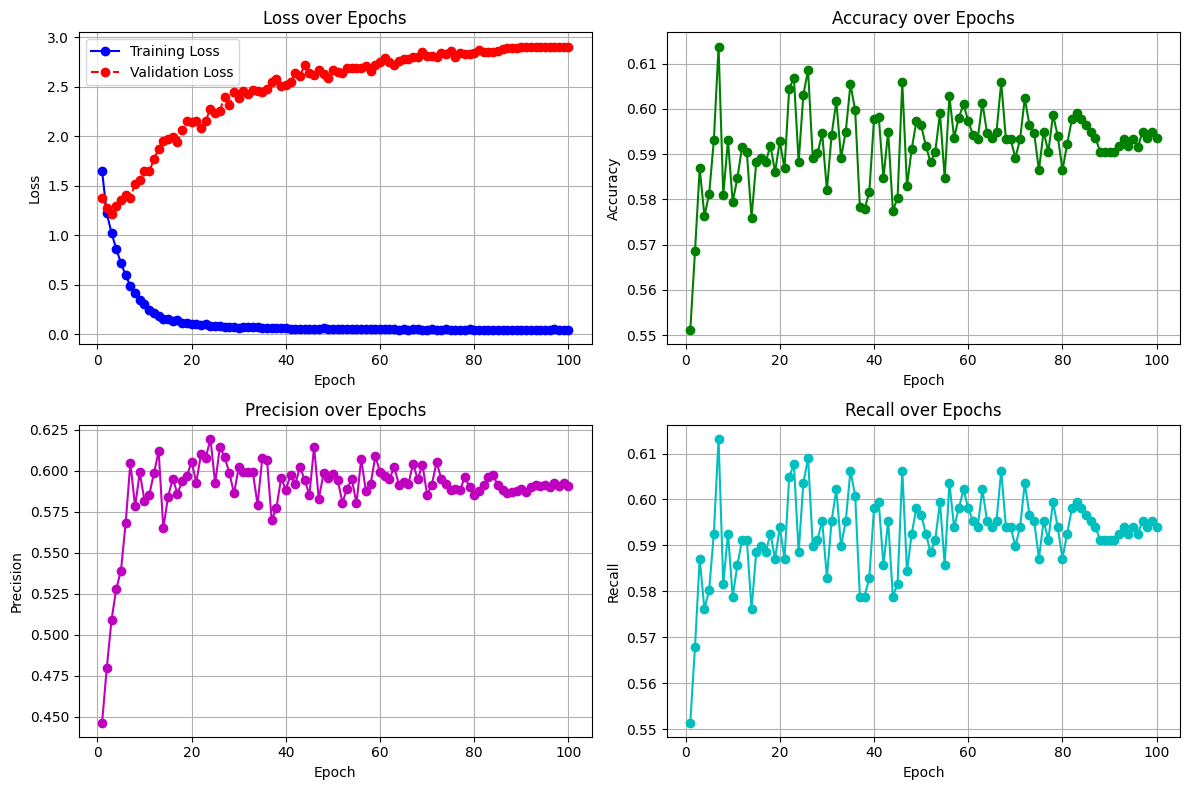

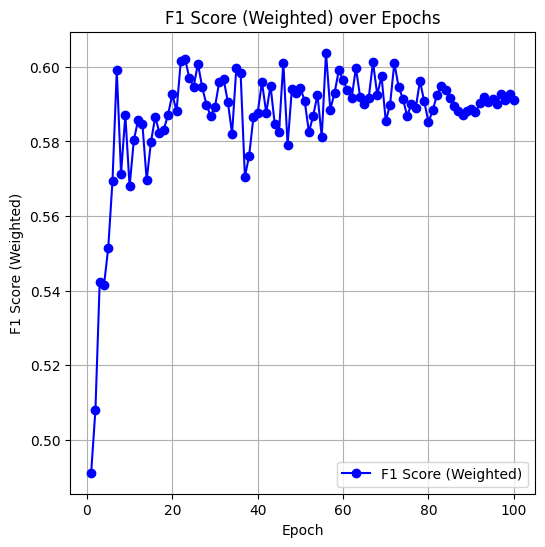

In [ ]:
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
training_stats = []

total_t0 = time.time()
best_epoch = 0

# For each epoch
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================
    # Perform one full pass over the training set.
    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()
    total_train_loss = 0
    model.train()
    for step, batch in enumerate(train_dataloader):
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        optimizer.zero_grad()
        output = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)
        loss = output.loss
        total_train_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0 to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Update parameters and take a step using the computed gradient.
        optimizer.step()
        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Save model checkpoint for the current epoch
    torch.save(model.state_dict(), f'.../categories_BERT_epoch_{epoch_i+1}.model')
    print(f'Model for epoch {epoch_i+1} saved in ".../categories_BERT_epoch_{epoch_i+1}.model"')
    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)
    print("")
    print("  Avg. training loss: {0:.3g}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))
    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.
    print("")
    print("Running Validation...")
    t0 = time.time()
    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()
    # Tracking variables
    predictions, true_vals = [], []
    total_eval_accuracy = 0
    best_eval_accuracy = 0
    total_eval_loss = 0
    nb_eval_steps = 0
    # Evaluate data for one epoch
    for batch in validation_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        # Tell pytorch not to bother with constructing the compute graph during
        # the forward pass, since this is only needed for backprop (training).
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask,
                                   labels=b_labels)
        loss = output.loss
        total_eval_loss += loss.item()
        # Move logits and labels to CPU if we are using GPU
        logits = output.logits
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate the accuracy for this batch of test sentences, and
        # accumulate it over all batches.
        total_eval_accuracy += flat_accuracy(logits, label_ids)

        predictions.append(logits)
        true_vals.append(label_ids)

    # Convert the predictions and true values to numpy arrays
    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    # Convert logits to predicted labels
    preds_flat = np.argmax(predictions, axis=1).flatten()
    labels_flat = true_vals.flatten()

    # Calculate the average loss over all of the batches.
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    print("")
    print("  Avg. validation loss: {0:.3g}".format(avg_val_loss))

    # Report the evaluation metrics for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Avg. accuracy: {0:.3g}".format(avg_val_accuracy))
    avg_val_recall = recall_score(labels_flat, preds_flat, average='weighted')
    print("  Avg. recall: {0:.3g}".format(avg_val_recall))
    avg_val_precision = precision_score(labels_flat, preds_flat, average='weighted', zero_division=0)
    print("  Avg. precision: {0:.3g}".format(avg_val_precision))
    avg_val_f1 = f1_score(labels_flat, preds_flat, average='weighted')
    print("  Avg. F1: {0:.3g}".format(avg_val_f1))

    # Measure how long the validation run took.
    validation_time = format_time(time.time() - t0)
    # Save the best model and track the epoch
    if avg_val_accuracy > best_eval_accuracy:
        torch.save(model, 'bert_model')
        best_eval_accuracy = avg_val_accuracy
        best_epoch = epoch_i + 1  # Store the best epoch (1-based index)

    print("  Validation took: {:}".format(validation_time))
    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Time': training_time,
            'Training Loss': avg_train_loss,
            'Validation Time': validation_time,
            'Validation Loss': avg_val_loss,
            'Validation Accuracy': avg_val_accuracy,
            'Validation Precision': avg_val_precision,
            'Validation Recall': avg_val_recall,
            'Validation F1': avg_val_f1
        }
    )
print("")
print("Training complete!")
print(f"Best model with avg. accuracy = {best_eval_accuracy:.3g} saved at epoch {best_epoch}!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))

file_path = '.../PS_S_categories_training_stats_metrics.pkl'
with open(file_path, 'wb') as f:
    pickle.dump(training_stats, f)

df = pd.DataFrame(training_stats)
file_path = '.../PS_S_categories_training_stats_metrics.xlsx'
df.to_excel(file_path, index=False)

epochs = [entry['epoch'] for entry in training_stats]
training_losses = [entry['Training Loss'] for entry in training_stats]
validation_losses = [entry['Validation Loss'] for entry in training_stats]
validation_accuracy = [entry['Validation Accuracy'] for entry in training_stats]
validation_precision = [entry['Validation Precision'] for entry in training_stats]
validation_recall = [entry['Validation Recall'] for entry in training_stats]
validation_f1 = [entry['Validation F1'] for entry in training_stats]
# Plot training and validation loss
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs, training_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.plot(epochs, validation_losses, marker='o', linestyle='--', color='r', label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, validation_accuracy, marker='o', linestyle='-', color='g', label='Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot precision
plt.subplot(2, 2, 3)
plt.plot(epochs, validation_precision, marker='o', linestyle='-', color='m', label='Precision')
plt.title('Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)

# Plot recall
plt.subplot(2, 2, 4)
plt.plot(epochs, validation_recall, marker='o', linestyle='-', color='c', label='Recall')
plt.title('Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot F1 Score
plt.figure(figsize=(6, 6))
plt.plot(epochs, validation_f1, marker='o', linestyle='-', color='b', label='F1 Score (Weighted)')
plt.title('F1 Score (Weighted) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score (Weighted)')
plt.grid(True)
plt.legend()
plt.show()

======== Epoch 7 / 100 ========

Training...

Model for epoch 7 saved in ".../categories_BERT_epoch_7.model"

  Avg. training loss: 0.487
  Training epoch took: 0:01:02

Running Validation...

  Avg. validation loss: 1.38
  Avg. accuracy: 0.614
  Avg. recall: 0.613
  Avg. precision: 0.605
  Avg. F1: 0.599
  Validation took: 0:00:05

### Implementing finetune BERT model on *test_df*

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


912
Classification Report:
               precision    recall  f1-score   support

         SS1      0.273     0.140     0.185        43
         SS2      0.567     0.694     0.624       245
         SS3      0.274     0.329     0.299        70
         SS4      1.000     0.167     0.286         6
         SS5      0.583     0.368     0.452        19
         SS6      0.250     0.040     0.069        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.698     0.698     0.698       318
         SC2      0.626     0.622     0.624       172

   micro avg      0.589     0.589     0.589       912
   macro avg      0.427     0.306     0.324       912
weighted avg      0.573     0.589     0.573       912
 samples avg      0.589     0.589     0.589       912

Accuracy: 0.589
Precision: 0.573
Recall: 0.589
F1 Score: 0.573



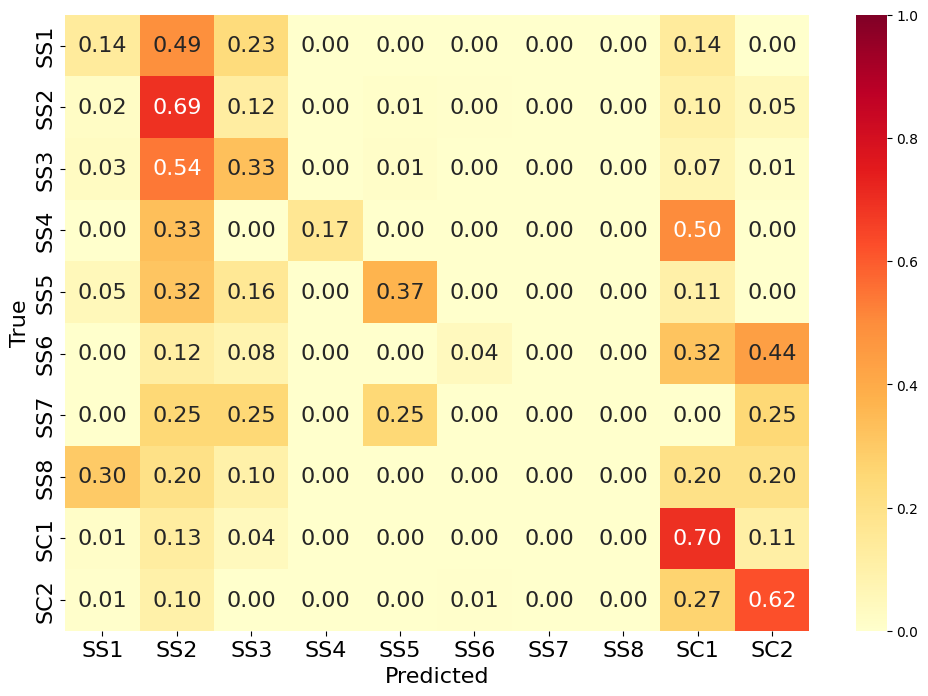

In [ ]:
%reset -f
import numpy as np
import pandas as pd
import time
import datetime
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler,random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import transformers
from transformers import BertForSequenceClassification, BertConfig,BertTokenizer,get_linear_schedule_with_warmup
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 10,
    output_attentions = False,
    output_hidden_states = False,
)

model = model.to(device)
model.load_state_dict(torch.load('.../categories_BERT_epoch_7.model', map_location=torch.device('cpu')))

df = pd.read_pickle('.../PS_S_df_test_df.pkl')
df['Utterance'] = df['Utterance'].astype(str)
print(len(df))

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32

test_input_ids = []
test_attention_masks = []
for utterance in df['Utterance']:
    encoded_dict = tokenizer(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        max_length=128,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(test_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

predictions = []
for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask)
            logits = output.logits
            logits = logits.detach().cpu().numpy()
            pred_flat = np.argmax(logits, axis=1).flatten()

            predictions.extend(list(pred_flat))

df['target'] = predictions
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

true_vals = df["label"].values  # True labels from df
predictions = df["target"].values  # Predicted labels from df

y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

# **Classification on Affective Dimension**

### Library/Module Import

In [ ]:
%reset -f
import numpy as np
import pandas as pd
import time
import datetime
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler,random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import transformers
from transformers import BertForSequenceClassification, AdamW, BertConfig,BertTokenizer,get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

### Preprocessing of dataset, *train_df* filtered on ['Dimension'] == 'affective'

In [ ]:
with open('.../train_df.pkl', 'rb') as f:
    train_df = pickle.load(f)
train_df = train_df[train_df['Dimension'] == 'affective']
# Ensure the utterance is string format
train_df['Utterance'] = train_df['Utterance'].astype(str)
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}
print("\nLabel Dictionary")
print(label_dict)
train_df['label'] = train_df['Categories'].map(label_dict)


Label Dictionary
{'AS1': 0, 'AS2': 1, 'AS3': 2}


### BERT Tokenizer

In [ ]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

input_ids = []
attention_masks = []

for utterance in train_df["Utterance"]:
    encoded_dict = tokenizer.encode_plus(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )

    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

labels = train_df.label.values
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

#### Train-validation split
80% of data is split into train and 20% to validation sets.

In [ ]:
dataset = TensorDataset(input_ids, attention_masks, labels)

train_size = int(0.8 * len(dataset))
val_size = len(dataset)  - train_size

torch.manual_seed(42)
# Divide the dataset by randomly selecting samples.
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print('{:>5,} training samples'.format(train_size))
print('{:>5,} validation samples'.format(val_size))

batch_size = 32

train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

validation_dataloader = DataLoader(
            val_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 3,
    output_attentions = False,
    output_hidden_states = False,
)

model = model.to(device)

optimizer = AdamW(model.parameters(),
                  lr = 2e-5,
                  eps = 1e-8
                )

  977 training samples
  245 validation samples


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


### Fine tuning the model

In [ ]:
# Number of training epochs
epochs = 100

# Total number of training steps is [number of batches] x [number of epochs].
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0,
                                            num_training_steps = total_steps)

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))


======== Epoch 1 / 100 ========
Training...
Model for epoch 1 saved in "/content/drive/MyDrive/AIED25/M2_BERT/AFFECTIVE_EPOCH/categories_BERT_epoch_1.model"

  Avg. training loss: 0.65
  Training epoch took: 0:00:28

Running Validation...

  Avg. validation loss: 0.398
  Avg. accuracy: 0.876
  Avg. recall: 0.882
  Avg. precision: 0.863
  Avg. F1: 0.872
  Validation took: 0:00:02

======== Epoch 2 / 100 ========
Training...
Model for epoch 2 saved in "/content/drive/MyDrive/AIED25/M2_BERT/AFFECTIVE_EPOCH/categories_BERT_epoch_2.model"

  Avg. training loss: 0.304
  Training epoch took: 0:00:25

Running Validation...

  Avg. validation loss: 0.337
  Avg. accuracy: 0.884
  Avg. recall: 0.886
  Avg. precision: 0.869
  Avg. F1: 0.876
  Validation took: 0:00:02

======== Epoch 3 / 100 ========
Training...
Model for epoch 3 saved in "/content/drive/MyDrive/AIED25/M2_BERT/AFFECTIVE_EPOCH/categories_BERT_epoch_3.model"

  Avg. training loss: 0.196
  Training epoch took: 0:00:27

Running Valida

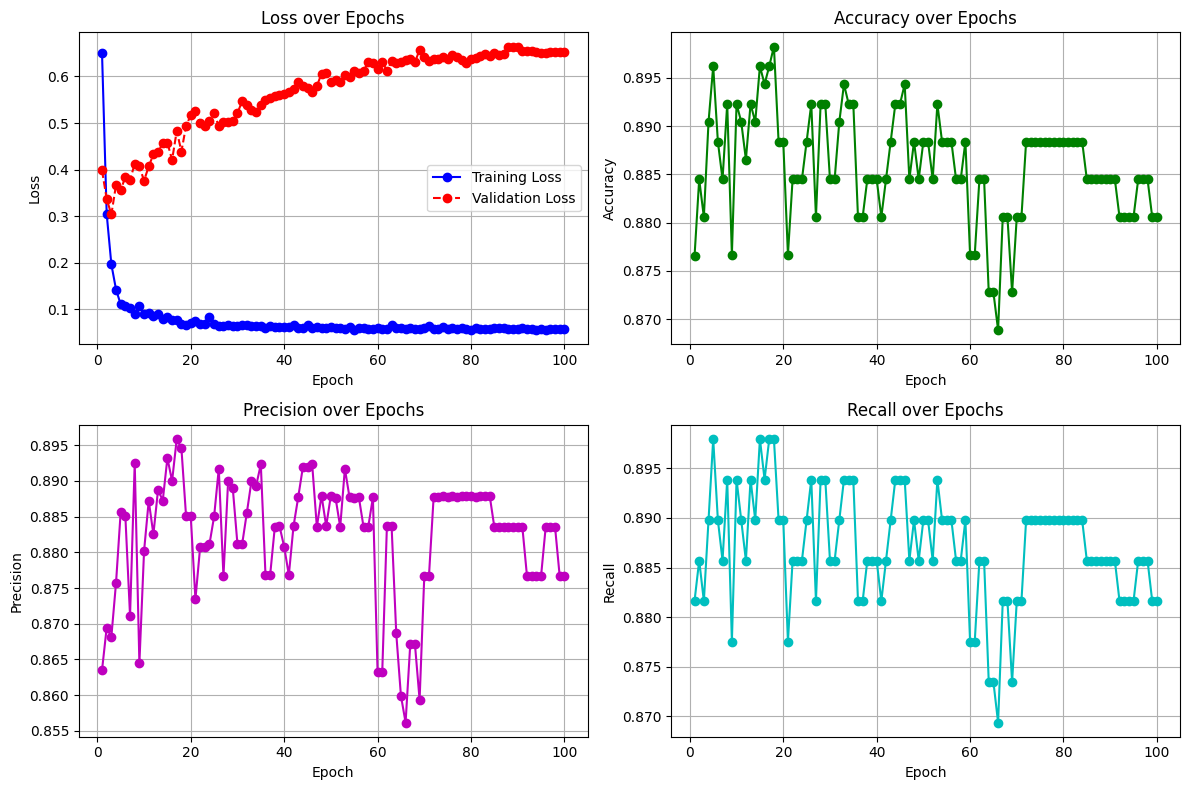

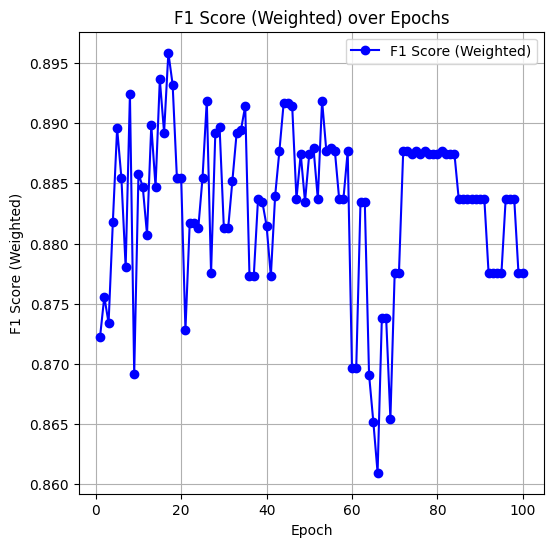

In [ ]:
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()
best_epoch = 0

# For each epoch
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================
    # Perform one full pass over the training set.
    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')
    # Measure how long the training epoch takes.
    t0 = time.time()
    total_train_loss = 0
    model.train()
    for step, batch in enumerate(train_dataloader):
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        optimizer.zero_grad()
        output = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)
        loss = output.loss
        total_train_loss += loss.item()

        loss.backward()
        # Clip the norm of the gradients to 1.0 to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Update parameters and take a step using the computed gradient.
        optimizer.step()
        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Save model checkpoint for the current epoch
    torch.save(model.state_dict(), f'.../categories_BERT_epoch_{epoch_i+1}.model')
    print(f'Model for epoch {epoch_i+1} saved in ".../categories_BERT_epoch_{epoch_i+1}.model"')
    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)
    print("")
    print("  Avg. training loss: {0:.3g}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))
    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.
    print("")
    print("Running Validation...")
    t0 = time.time()
    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()
    # Tracking variables
    predictions, true_vals = [], []
    total_eval_accuracy = 0
    best_eval_accuracy = 0
    total_eval_loss = 0
    nb_eval_steps = 0
    # Evaluate data for one epoch
    for batch in validation_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask,
                                   labels=b_labels)
        loss = output.loss
        total_eval_loss += loss.item()

        logits = output.logits
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        total_eval_accuracy += flat_accuracy(logits, label_ids)

        predictions.append(logits)
        true_vals.append(label_ids)

    # Convert the predictions and true values to numpy arrays
    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    # Convert logits to predicted labels
    preds_flat = np.argmax(predictions, axis=1).flatten()
    labels_flat = true_vals.flatten()

    # Calculate the average loss over all of the batches.
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    print("")
    print("  Avg. validation loss: {0:.3g}".format(avg_val_loss))

    # Report the evaluation metrics for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Avg. accuracy: {0:.3g}".format(avg_val_accuracy))
    avg_val_recall = recall_score(labels_flat, preds_flat, average='weighted')
    print("  Avg. recall: {0:.3g}".format(avg_val_recall))
    avg_val_precision = precision_score(labels_flat, preds_flat, average='weighted', zero_division=0)
    print("  Avg. precision: {0:.3g}".format(avg_val_precision))
    avg_val_f1 = f1_score(labels_flat, preds_flat, average='weighted')
    print("  Avg. F1: {0:.3g}".format(avg_val_f1))

    validation_time = format_time(time.time() - t0)
    if avg_val_accuracy > best_eval_accuracy:
        torch.save(model, 'bert_model')
        best_eval_accuracy = avg_val_accuracy
        best_epoch = epoch_i + 1

    print("  Validation took: {:}".format(validation_time))

    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Time': training_time,
            'Training Loss': avg_train_loss,
            'Validation Time': validation_time,
            'Validation Loss': avg_val_loss,
            'Validation Accuracy': avg_val_accuracy,
            'Validation Precision': avg_val_precision,
            'Validation Recall': avg_val_recall,
            'Validation F1': avg_val_f1
        }
    )
print("")
print("Training complete!")
print(f"Best model with avg. accuracy = {best_eval_accuracy:.3g} saved at epoch {best_epoch}!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


file_path = '.../AFFECTIVE_categories_training_stats_metrics.pkl'
with open(file_path, 'wb') as f:
    pickle.dump(training_stats, f)


df = pd.DataFrame(training_stats)
file_path = '.../AFFECTIVE_categories_training_stats_metrics.xlsx'
df.to_excel(file_path, index=False)

epochs = [entry['epoch'] for entry in training_stats]
training_losses = [entry['Training Loss'] for entry in training_stats]
validation_losses = [entry['Validation Loss'] for entry in training_stats]
validation_accuracy = [entry['Validation Accuracy'] for entry in training_stats]
validation_precision = [entry['Validation Precision'] for entry in training_stats]
validation_recall = [entry['Validation Recall'] for entry in training_stats]
validation_f1 = [entry['Validation F1'] for entry in training_stats]
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs, training_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.plot(epochs, validation_losses, marker='o', linestyle='--', color='r', label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, validation_accuracy, marker='o', linestyle='-', color='g', label='Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot precision
plt.subplot(2, 2, 3)
plt.plot(epochs, validation_precision, marker='o', linestyle='-', color='m', label='Precision')
plt.title('Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)

# Plot recall
plt.subplot(2, 2, 4)
plt.plot(epochs, validation_recall, marker='o', linestyle='-', color='c', label='Recall')
plt.title('Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(epochs, validation_f1, marker='o', linestyle='-', color='b', label='F1 Score (Weighted)')
plt.title('F1 Score (Weighted) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score (Weighted)')
plt.grid(True)
plt.legend()
plt.show()

======== Epoch 3 / 100 ========

Training...

Model for epoch 3 saved in ".../categories_BERT_epoch_3.model"

  Avg. training loss: 0.196
  Training epoch took: 0:00:27

Running Validation...

  Avg. validation loss: 0.303
  Avg. accuracy: 0.881
  Avg. recall: 0.882
  Avg. precision: 0.868
  Avg. F1: 0.873
  Validation took: 0:00:02

### Implementing finetune BERT model on *AFFECTIVE_df_test*

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Classification Report:
               precision    recall  f1-score   support

         AS1      0.871     0.886     0.878       114
         AS2      0.904     0.924     0.914       184
         AS3      1.000     0.250     0.400         8

   micro avg      0.892     0.892     0.892       306
   macro avg      0.925     0.687     0.731       306
weighted avg      0.894     0.892     0.887       306
 samples avg      0.892     0.892     0.892       306

Accuracy: 0.892
Precision: 0.894
Recall: 0.892
F1 Score: 0.887



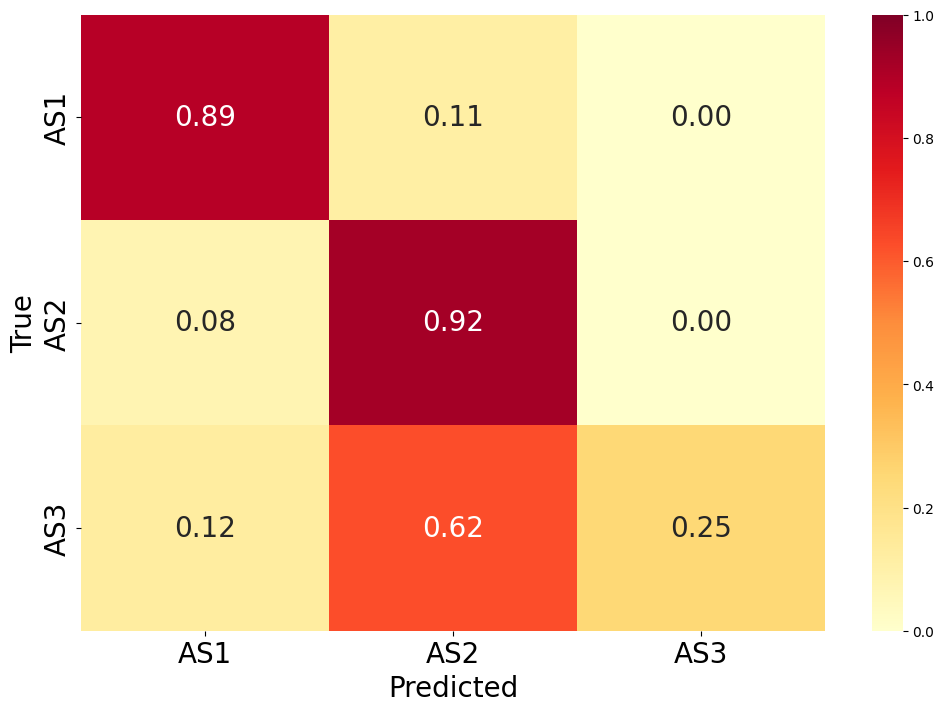

In [ ]:
%reset -f
import numpy as np
import pandas as pd
import time
import datetime
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler,random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import transformers
from transformers import BertForSequenceClassification, BertConfig,BertTokenizer,get_linear_schedule_with_warmup
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 3,
    output_attentions = False,
    output_hidden_states = False,
)

model = model.to(device)
model.load_state_dict(torch.load('.../categories_BERT_epoch_3.model', map_location=torch.device('cpu')))

df = pd.read_pickle('.../AFFECTIVE_df_test.pkl')
df['Utterance'] = df['Utterance'].astype(str)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32

test_input_ids = []
test_attention_masks = []
for utterance in df['Utterance']:
    encoded_dict = tokenizer(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(test_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

predictions = []
for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask)
            logits = output.logits
            logits = logits.detach().cpu().numpy()
            pred_flat = np.argmax(logits, axis=1).flatten()

            predictions.extend(list(pred_flat))

df['target'] = predictions
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

true_vals = df["label"].values  # True labels from df
predictions = df["target"].values  # Predicted labels from df

y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()